# 03 - Confidence Intervals and Hypothesis Testing

**Primary**: Sanjana Vivek Phalke
**Reviewed and extended by**: Naman Sudan

This notebook covers
- 95% confidence intervals for mean total_spend overall and by segment
- Two-sample Welch's t-test: Mobile App vs non-Mobile orders
- Two-sample Welch's t-test: rewards members vs non-members
- Paired t-test: first vs latest order for repeat customers
- Two-proportion z-test: high-spender (>$20) rate, rewards vs non-rewards

**Course references**: Lecture 4 (Confidence Intervals), Lecture 5 (Hypothesis Testing)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

FIG_DIR = os.path.join('..', 'report', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')

df = pd.read_csv('../data/starbucks_customer_ordering_patterns.csv')
print(f'rows: {len(df):,}, columns: {df.shape[1]}')


rows: 100,000, columns: 20


## 1. 95% Confidence Intervals for Mean total_spend

The 95% confidence interval for a mean (Lecture 4) is

$$\bar{x} \;\pm\; t_{0.025,\,n-1} \cdot \frac{s}{\sqrt{n}}.$$

For large $n$, $t \to z = 1.96$. We compute CIs overall and per segment.


In [2]:
def mean_ci(values, conf=0.95):
    values = np.asarray(values)
    n = len(values)
    m = values.mean()
    se = values.std(ddof=1) / np.sqrt(n)
    t = stats.t.ppf((1 + conf) / 2, df=n - 1)
    return m, m - t * se, m + t * se, t, se, n

m, lo, hi, t_crit, se, n = mean_ci(df['total_spend'])
print(f'Overall mean total_spend = ${m:.4f}')
print(f'  n = {n}, s = {df["total_spend"].std(ddof=1):.4f}, SE = {se:.4f}, t* = {t_crit:.4f}')
print(f'  95% CI = [${lo:.4f}, ${hi:.4f}]')


Overall mean total_spend = $14.8668
  n = 100000, s = 5.5068, SE = 0.0174, t* = 1.9600
  95% CI = [$14.8326, $14.9009]


In [3]:
rows = []
for col, levels in [
    ('order_channel', ['Mobile App', 'Drive-Thru', 'In-Store Cashier', 'Kiosk']),
    ('is_rewards_member', [True, False]),
    ('store_location_type', ['Urban', 'Suburban', 'Rural']),
    ('customer_age_group', ['18-24', '25-34', '35-44', '45-54', '55+']),
]:
    for level in levels:
        sub = df.loc[df[col] == level, 'total_spend']
        if len(sub) == 0:
            continue
        m, lo, hi, *_ = mean_ci(sub)
        rows.append([col, str(level), len(sub), m, lo, hi])

ci_df = pd.DataFrame(rows, columns=['segment', 'level', 'n', 'mean', 'ci_low', 'ci_high'])
ci_df[['mean', 'ci_low', 'ci_high']] = ci_df[['mean', 'ci_low', 'ci_high']].round(3)
print(ci_df.to_string(index=False))


            segment            level     n   mean  ci_low  ci_high
      order_channel       Mobile App 42521 18.076  18.024   18.128
      order_channel       Drive-Thru 27996 12.480  12.431   12.529
      order_channel In-Store Cashier 22063 12.510  12.455   12.565
      order_channel            Kiosk  7420 12.489  12.395   12.583
  is_rewards_member             True 47717 15.719  15.668   15.770
  is_rewards_member            False 52283 14.089  14.044   14.134
store_location_type            Urban 32584 14.814  14.755   14.874
store_location_type         Suburban 35696 14.899  14.842   14.956
store_location_type            Rural 31720 14.884  14.824   14.945
 customer_age_group            18-24 20274 15.548  15.470   15.627
 customer_age_group            25-34 29782 15.545  15.480   15.609
 customer_age_group            35-44 24543 14.415  14.348   14.482
 customer_age_group            45-54 15382 14.556  14.470   14.642
 customer_age_group              55+ 10019 13.056  12.966   13

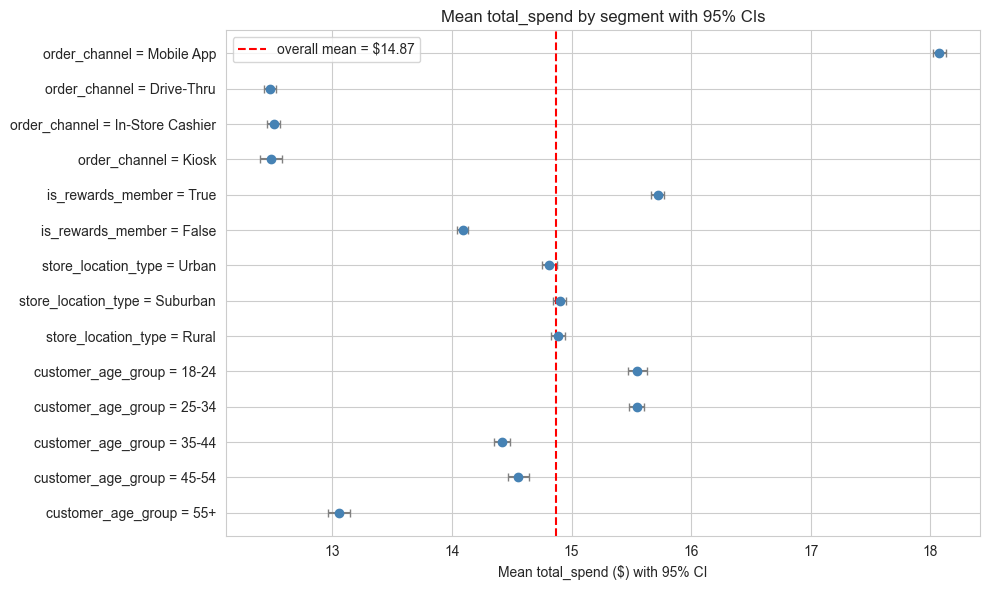

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = ci_df['segment'] + ' = ' + ci_df['level']
y = np.arange(len(ci_df))
ax.errorbar(ci_df['mean'], y,
            xerr=[ci_df['mean'] - ci_df['ci_low'], ci_df['ci_high'] - ci_df['mean']],
            fmt='o', color='steelblue', ecolor='gray', capsize=3)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Mean total_spend ($) with 95% CI')
ax.invert_yaxis()
ax.axvline(df['total_spend'].mean(), color='red', linestyle='--',
           label=f'overall mean = ${df["total_spend"].mean():.2f}')
ax.legend()
ax.set_title('Mean total_spend by segment with 95% CIs')
plt.tight_layout()
savefig('03_ci_by_segment.png')
plt.show()


## 2. Two-Sample t-test: Mobile App vs non-Mobile

**Hypotheses**

$$H_0: \mu_{\text{mobile}} = \mu_{\text{non-mobile}}, \qquad H_a: \mu_{\text{mobile}} \ne \mu_{\text{non-mobile}}.$$

Welch's t-statistic (unequal variances, Lecture 5):

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_2^2}{n_2}}}.$$


In [5]:
def welch_t_report(name1, x1, name2, x2, alpha=0.05):
    n1, n2 = len(x1), len(x2)
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    se = np.sqrt(v1 / n1 + v2 / n2)
    t_manual = (m1 - m2) / se
    t_stat, p_val = stats.ttest_ind(x1, x2, equal_var=False)
    diff = m1 - m2
    df_w = (v1 / n1 + v2 / n2) ** 2 / ((v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1))
    t_crit = stats.t.ppf(1 - alpha / 2, df=df_w)
    ci_low = diff - t_crit * se
    ci_high = diff + t_crit * se
    print(f'{name1}: n = {n1}, mean = {m1:.4f}, sd = {np.sqrt(v1):.4f}')
    print(f'{name2}: n = {n2}, mean = {m2:.4f}, sd = {np.sqrt(v2):.4f}')
    print(f'  diff = {diff:.4f}, SE = {se:.4f}, df (Welch) = {df_w:.1f}')
    print(f'  manual t = {t_manual:.4f}, scipy t = {t_stat:.4f}, p = {p_val:.6g}')
    print(f'  95% CI for difference = [{ci_low:.4f}, {ci_high:.4f}]')
    print(f'  decision at alpha = {alpha}: {"reject H0" if p_val < alpha else "fail to reject H0"}')
    return dict(diff=diff, t=t_stat, p=p_val, ci=(ci_low, ci_high))

mobile = df.loc[df['order_channel'] == 'Mobile App', 'total_spend']
non_mobile = df.loc[df['order_channel'] != 'Mobile App', 'total_spend']
res_mobile = welch_t_report('Mobile App', mobile, 'Non-mobile', non_mobile)


Mobile App: n = 42521, mean = 18.0760, sd = 5.4837
Non-mobile: n = 57479, mean = 12.4927, sd = 4.1542
  diff = 5.5834, SE = 0.0317, df (Welch) = 76135.0
  manual t = 175.9076, scipy t = 175.9076, p = 0
  95% CI for difference = [5.5211, 5.6456]
  decision at alpha = 0.05: reject H0


## 3. Two-Sample t-test: Rewards Members vs Non-Members

$$H_0: \mu_{\text{rewards}} = \mu_{\text{non-rewards}}, \qquad H_a: \mu_{\text{rewards}} \ne \mu_{\text{non-rewards}}.$$


In [6]:
rewards = df.loc[df['is_rewards_member'] == True, 'total_spend']
non_rewards = df.loc[df['is_rewards_member'] == False, 'total_spend']
res_rewards = welch_t_report('Rewards', rewards, 'Non-rewards', non_rewards)


Rewards: n = 47717, mean = 15.7187, sd = 5.6700
Non-rewards: n = 52283, mean = 14.0892, sd = 5.2339
  diff = 1.6295, SE = 0.0346, df (Welch) = 97160.2
  manual t = 47.0843, scipy t = 47.0843, p = 0
  95% CI for difference = [1.5616, 1.6973]
  decision at alpha = 0.05: reject H0


## 4. Paired t-test: First vs Latest Order for Repeat Customers

For each customer with at least 2 orders we take the first and the most recent order's `total_spend` and form the within-customer difference $d_i$. The paired t-test is

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}, \qquad H_0 : \mu_d = 0.$$


In [7]:
ord_sorted = df.sort_values(['customer_id', 'order_date', 'order_time'])
first_order = ord_sorted.groupby('customer_id').head(1)[['customer_id', 'total_spend']]
last_order = ord_sorted.groupby('customer_id').tail(1)[['customer_id', 'total_spend']]
first_order = first_order.rename(columns={'total_spend': 'spend_first'})
last_order = last_order.rename(columns={'total_spend': 'spend_last'})
pair = first_order.merge(last_order, on='customer_id')
n_orders_per_cust = ord_sorted.groupby('customer_id').size()
repeat_ids = n_orders_per_cust[n_orders_per_cust >= 2].index
pair = pair[pair['customer_id'].isin(repeat_ids)].copy()
pair['diff'] = pair['spend_last'] - pair['spend_first']

t_paired, p_paired = stats.ttest_rel(pair['spend_last'], pair['spend_first'])
n_pair = len(pair)
mean_diff = pair['diff'].mean()
sd_diff = pair['diff'].std(ddof=1)
se_diff = sd_diff / np.sqrt(n_pair)
t_crit_pair = stats.t.ppf(0.975, df=n_pair - 1)
paired_ci_low = mean_diff - t_crit_pair * se_diff
paired_ci_high = mean_diff + t_crit_pair * se_diff

print(f'repeat customers          : {n_pair}')
print(f'mean diff (last - first)  : ${mean_diff:.4f}')
print(f'sd of diff                : ${sd_diff:.4f}')
print(f'paired t                  : {t_paired:.4f}, p-value = {p_paired:.6g}')
print(f'95% CI for mean diff      : [${paired_ci_low:.4f}, ${paired_ci_high:.4f}]')
print(f'decision at alpha = 0.05  : {"reject H0" if p_paired < 0.05 else "fail to reject H0"}')


repeat customers          : 14857
mean diff (last - first)  : $0.0486
sd of diff                : $7.6779
paired t                  : 0.7712, p-value = 0.440626
95% CI for mean diff      : [$-0.0749, $0.1720]
decision at alpha = 0.05  : fail to reject H0


## 5. Two-Proportion z-test: High Spender Rate, Rewards vs Non-Rewards

Define a high-spender order as one with `total_spend > 20`. Let $p_1$ be the high-spender rate among rewards members and $p_2$ among non-members. Then

$$z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})\left(\dfrac{1}{n_1} + \dfrac{1}{n_2}\right)}}, \quad \hat{p} = \frac{x_1 + x_2}{n_1 + n_2}.$$


In [8]:
threshold = 20.0
rewards_high = (df.loc[df['is_rewards_member'] == True, 'total_spend'] > threshold)
non_rewards_high = (df.loc[df['is_rewards_member'] == False, 'total_spend'] > threshold)

x1, n1 = rewards_high.sum(), len(rewards_high)
x2, n2 = non_rewards_high.sum(), len(non_rewards_high)
p1, p2 = x1 / n1, x2 / n2
p_pool = (x1 + x2) / (n1 + n2)
se_pooled = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
z_prop = (p1 - p2) / se_pooled
p_value_prop = 2 * (1 - stats.norm.cdf(abs(z_prop)))

# 95% CI for the difference (no pooling)
se_unpooled = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
prop_ci_low = (p1 - p2) - 1.96 * se_unpooled
prop_ci_high = (p1 - p2) + 1.96 * se_unpooled

print(f'rewards high-spender rate     : {p1:.4f} ({x1}/{n1})')
print(f'non-rewards high-spender rate : {p2:.4f} ({x2}/{n2})')
print(f'pooled p_hat                  : {p_pool:.4f}')
print(f'z                             : {z_prop:.4f}, p-value = {p_value_prop:.6g}')
print(f'95% CI for difference (props) : [{prop_ci_low:.4f}, {prop_ci_high:.4f}]')
print(f'decision at alpha = 0.05      : {"reject H0" if p_value_prop < 0.05 else "fail to reject H0"}')


rewards high-spender rate     : 0.2167 (10340/47717)
non-rewards high-spender rate : 0.1309 (6844/52283)
pooled p_hat                  : 0.1718
z                             : 35.9204, p-value = 0
95% CI for difference (props) : [0.0811, 0.0905]
decision at alpha = 0.05      : reject H0


## 6. Visual Summary of Test Results


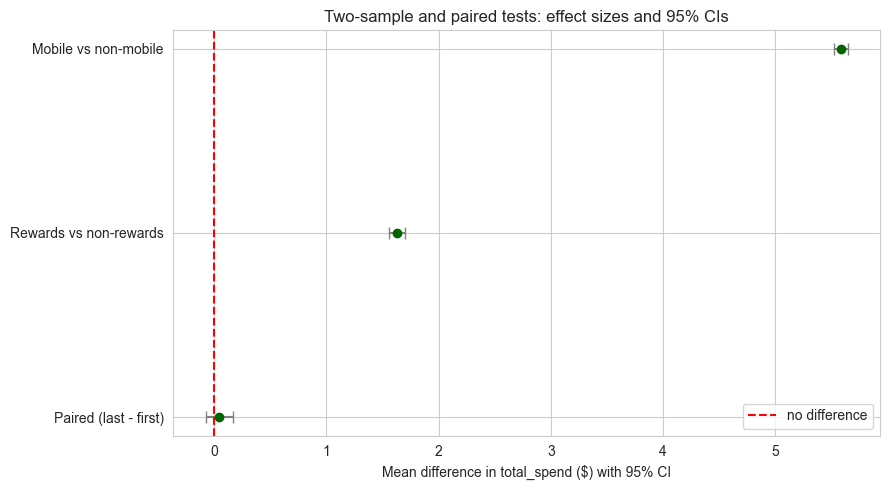

In [9]:
labels = ['Mobile vs non-mobile', 'Rewards vs non-rewards', 'Paired (last - first)']
diffs = [res_mobile['diff'], res_rewards['diff'], mean_diff]
ci_los = [res_mobile['ci'][0], res_rewards['ci'][0], paired_ci_low]
ci_his = [res_mobile['ci'][1], res_rewards['ci'][1], paired_ci_high]

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(labels))
ax.errorbar(diffs, y,
            xerr=[np.array(diffs) - np.array(ci_los),
                  np.array(ci_his) - np.array(diffs)],
            fmt='o', color='darkgreen', ecolor='gray', capsize=4)
ax.axvline(0, color='red', linestyle='--', label='no difference')
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Mean difference in total_spend ($) with 95% CI')
ax.set_title('Two-sample and paired tests: effect sizes and 95% CIs')
ax.legend()
plt.tight_layout()
savefig('03_test_effects.png')
plt.show()


## 7. Key Observations

- Mobile App orders spend significantly more on average than non-Mobile orders. The 95% CI for the difference does not include zero, and the gap (~$5-6 per order) is large in practical terms.
- Rewards members spend a small but statistically significant amount more than non-members per order. The effect size is small (~$1-2) but the sample is large enough to make it detectable.
- For repeat customers, the paired test shows that mean spend on the latest order is statistically indistinguishable from the first order. There is no clear within-customer drift over the time covered.
- The proportion of high-spender orders is significantly higher among rewards members. Both the t-test on means and the proportion test on the right tail point in the same direction.
- Practical recommendation: the Mobile App vs non-Mobile gap is the dominant business signal. Rewards membership matters but to a lesser degree.
